In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor

from sklearn.linear_model import Ridge


In [3]:
df=pd.read_csv(r"C:\Users\Toshiba\Downloads\ML Session 9\cashless_claim_prediction_dataset (1).csv")
df

,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,24-08-2024,62,Female,3.0,NaN,0.0,1,...,3915.0,10,10000,0,50974,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,11-04-2024,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,04-07-2023,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824,30179,8293,10292,61.0,48351
3,CLM00004997,PAT001322,HSP0077,28-06-2023,6,Male,1.0,NaN,0.0,2,...,2201.0,0,1000,0,59420,20321,8625,18688,64.0,35995
4,CLM00001759,PAT001541,HSP0114,12-01-2025,58,Male,1.0,23.1,0.0,2,...,1500.0,20,30000,0,105636,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CLM00001444,PAT000312,HSP0060,28-02-2024,33,Male,1.0,31.1,0.0,1,...,3812.0,5,10000,0,44763,15723,6485,9841,52.0,19385
4996,CLM00003506,PAT000082,HSP0017,04-10-2023,28,Female,1.0,25.7,0.0,3,...,1500.0,30,2000,0,63330,22358,15588,13009,74.0,25669
4997,CLM00003374,PAT000823,HSP0164,21-11-2023,64,Male,1.0,24.1,0.0,3,...,1500.0,10,2000,0,122105,55007,25200,28427,55.0,72412
4998,CLM00003850,PAT001755,HSP0197,17-01-2024,36,Male,1.0,27.4,0.0,2,...,1500.0,30,30000,0,115131,46046,27583,23221,72.0,25870


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   claim_id                           5000 non-null   object 
 1   patient_id                         5000 non-null   object 
 2   hospital_id                        5000 non-null   object 
 3   claim_submitted_date               5000 non-null   object 
 4   age                                5000 non-null   int64  
 5   gender                             5000 non-null   object 
 6   city_tier                          4951 non-null   float64
 7   bmi                                4779 non-null   float64
 8   smoker_flag                        4876 non-null   float64
 9   comorbidity_score                  5000 non-null   int64  
 10  prior_claim_count_2yr              5000 non-null   int64  
 11  prior_claim_amount_2yr             5000 non-null   int64

In [5]:
df.duplicated().sum()

np.int64(96)

In [6]:
df.drop_duplicates()

,claim_id,patient_id,hospital_id,claim_submitted_date,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,CLM00003551,PAT000616,HSP0197,24-08-2024,62,Female,3.0,NaN,0.0,1,...,3915.0,10,10000,0,50974,22119,7975,10083,100.0,20662
1,CLM00004880,PAT001780,HSP0151,11-04-2024,38,Male,2.0,29.0,0.0,0,...,5077.0,0,0,0,57113,22148,13163,11712,74.0,35592
2,CLM00000982,PAT000934,HSP0230,04-07-2023,50,Male,2.0,28.9,0.0,1,...,13989.0,5,1000,0,51824,30179,8293,10292,61.0,48351
3,CLM00004997,PAT001322,HSP0077,28-06-2023,6,Male,1.0,NaN,0.0,2,...,2201.0,0,1000,0,59420,20321,8625,18688,64.0,35995
4,CLM00001759,PAT001541,HSP0114,12-01-2025,58,Male,1.0,23.1,0.0,2,...,1500.0,20,30000,0,105636,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,CLM00003998,PAT000091,HSP0093,16-06-2025,57,Female,2.0,23.2,NaN,3,...,2046.0,10,30000,1,30725,8558,4846,5317,83.0,0
4995,CLM00001444,PAT000312,HSP0060,28-02-2024,33,Male,1.0,31.1,0.0,1,...,3812.0,5,10000,0,44763,15723,6485,9841,52.0,19385
4996,CLM00003506,PAT000082,HSP0017,04-10-2023,28,Female,1.0,25.7,0.0,3,...,1500.0,30,2000,0,63330,22358,15588,13009,74.0,25669
4997,CLM00003374,PAT000823,HSP0164,21-11-2023,64,Male,1.0,24.1,0.0,3,...,1500.0,10,2000,0,122105,55007,25200,28427,55.0,72412


In [7]:
df=df.drop(columns=[
   "claim_id",                              
   "patient_id",                           
   "hospital_id",                           
   "claim_submitted_date"
])

In [8]:
df.columns

Index(['age', 'gender', 'city_tier', 'bmi', 'smoker_flag', 'comorbidity_score',
       'prior_claim_count_2yr', 'prior_claim_amount_2yr', 'admission_type',
       'treatment_type', 'diagnosis_category', 'severity_level',
       'procedure_count', 'procedure_complexity_score', 'icu_days',
       'length_of_stay_days', 'pre_existing_disease_flag', 'hospital_type',
       'hospital_tier', 'network_hospital_flag',
       'hospital_historical_approval_rate', 'hospital_billing_index',
       'hospital_city_tier', 'policy_type', 'policy_tenure_months',
       'sum_insured', 'remaining_sum_insured', 'room_rent_limit_per_day',
       'copay_percent', 'deductible_amount', 'waiting_period_applicable_flag',
       'claimed_amount', 'room_charges', 'doctor_fees', 'medicine_charges',
       'document_quality_score', 'approved_amount'],
      dtype='object')

In [9]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
count,4904.000000,4855.000000,4685.000000,4781.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,...,4831.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4733.000000,4904.000000
mean,41.836868,1.899485,25.057994,0.174440,1.679853,0.669046,15422.783850,3.210033,1.465538,4.998144,...,3495.538605,8.675571,9581.566069,0.139886,60965.168026,23755.407219,11726.419046,12868.950245,71.665751,26671.730220
std,19.654862,0.807228,5.399448,0.379528,1.359759,0.804822,25516.108582,1.237433,1.298281,2.067607,...,2992.132704,10.727398,12573.385428,0.346904,31240.833575,13877.202035,7321.709952,7208.334998,15.495938,19660.354012
min,0.000000,1.000000,-3.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,1500.000000,0.000000,0.000000,0.000000,-5000.000000,2155.000000,1139.000000,1250.000000,2.000000,0.000000
25%,30.000000,1.000000,22.100000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,3.500000,...,1500.000000,0.000000,0.000000,0.000000,38742.250000,13990.500000,6385.750000,7825.000000,61.000000,12909.500000
50%,43.000000,2.000000,25.000000,0.000000,1.000000,0.000000,0.000000,3.000000,1.000000,4.900000,...,2035.000000,5.000000,5000.000000,0.000000,54778.500000,20457.000000,9810.500000,11312.000000,72.000000,23934.500000
75%,54.000000,3.000000,27.900000,0.000000,2.000000,1.000000,22048.500000,4.000000,2.000000,6.500000,...,4356.500000,15.000000,15000.000000,0.000000,76793.500000,30441.500000,15267.750000,16187.750000,83.000000,36975.500000
max,150.000000,3.000000,80.000000,1.000000,8.000000,5.000000,336714.000000,5.000000,8.000000,10.000000,...,20346.000000,120.000000,50000.000000,1.000000,259083.000000,113520.000000,60466.000000,79411.000000,100.000000,153439.000000


In [12]:
import numpy as np

# BMI → cannot be negative
df.loc[df["bmi"] < 0, "bmi"] = np.nan
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# Claimed amount → cannot be negative
df.loc[df["claimed_amount"] < 0, "claimed_amount"] = np.nan
df["claimed_amount"] = df["claimed_amount"].fillna(0)

In [13]:
df.describe()

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
count,4904.000000,4855.000000,4904.000000,4781.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,...,4831.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4904.000000,4733.000000,4904.000000
mean,41.836868,1.899485,25.101896,0.174440,1.679853,0.669046,15422.783850,3.210033,1.465538,4.998144,...,3495.538605,8.675571,9581.566069,0.139886,60975.363785,23755.407219,11726.419046,12868.950245,71.665751,26671.730220
std,19.654862,0.807228,5.149694,0.379528,1.359759,0.804822,25516.108582,1.237433,1.298281,2.067607,...,2992.132704,10.727398,12573.385428,0.346904,31220.108319,13877.202035,7321.709952,7208.334998,15.495938,19660.354012
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,1500.000000,0.000000,0.000000,0.000000,0.000000,2155.000000,1139.000000,1250.000000,2.000000,0.000000
25%,30.000000,1.000000,22.200000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,3.500000,...,1500.000000,0.000000,0.000000,0.000000,38742.250000,13990.500000,6385.750000,7825.000000,61.000000,12909.500000
50%,43.000000,2.000000,25.000000,0.000000,1.000000,0.000000,0.000000,3.000000,1.000000,4.900000,...,2035.000000,5.000000,5000.000000,0.000000,54778.500000,20457.000000,9810.500000,11312.000000,72.000000,23934.500000
75%,54.000000,3.000000,27.800000,0.000000,2.000000,1.000000,22048.500000,4.000000,2.000000,6.500000,...,4356.500000,15.000000,15000.000000,0.000000,76793.500000,30441.500000,15267.750000,16187.750000,83.000000,36975.500000
max,150.000000,3.000000,80.000000,1.000000,8.000000,5.000000,336714.000000,5.000000,8.000000,10.000000,...,20346.000000,120.000000,50000.000000,1.000000,259083.000000,113520.000000,60466.000000,79411.000000,100.000000,153439.000000


In [14]:
df["city_tier"] = df["city_tier"].fillna(df["city_tier"].mode()[0])
df["smoker_flag"] = df["smoker_flag"].fillna(df["smoker_flag"].mode()[0])

df["bmi"] = df["bmi"].fillna(df["bmi"].median())
df["hospital_billing_index"] = df["hospital_billing_index"].fillna(df["hospital_billing_index"].median())
df["room_rent_limit_per_day"] = df["room_rent_limit_per_day"].fillna(df["room_rent_limit_per_day"].median())
df["document_quality_score"] = df["document_quality_score"].fillna(df["document_quality_score"].median())


In [15]:
df.isnull().sum()

age                                  0
gender                               0
city_tier                            0
bmi                                  0
smoker_flag                          0
comorbidity_score                    0
prior_claim_count_2yr                0
prior_claim_amount_2yr               0
admission_type                       0
treatment_type                       0
diagnosis_category                   0
severity_level                       0
procedure_count                      0
procedure_complexity_score           0
icu_days                             0
length_of_stay_days                  0
pre_existing_disease_flag            0
hospital_type                        0
hospital_tier                        0
network_hospital_flag                0
hospital_historical_approval_rate    0
hospital_billing_index               0
hospital_city_tier                   0
policy_type                          0
policy_tenure_months                 0
sum_insured              

In [16]:
df["gender"].value_counts()

gender
Male       2578
Female     2173
Other       105
F            17
Unknown      17
M            14
Name: count, dtype: int64

In [17]:
df["gender"]=df["gender"].replace({
    "F":"Female",
    "Unknown":"Other",
    "M":"Male"
})

In [18]:
df["gender"].value_counts()

gender
Male      2592
Female    2190
Other      122
Name: count, dtype: int64

In [19]:
df

,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,admission_type,treatment_type,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,62,Female,3.0,25.0,0.0,1,0,0,Emergency,Non-Surgery,...,3915.0,10,10000,0,50974.0,22119,7975,10083,100.0,20662
1,38,Male,2.0,29.0,0.0,0,1,51576,Planned,Surgery,...,5077.0,0,0,0,57113.0,22148,13163,11712,74.0,35592
2,50,Male,2.0,28.9,0.0,1,0,0,Emergency,Non-Surgery,...,13989.0,5,1000,0,51824.0,30179,8293,10292,61.0,48351
3,6,Male,1.0,25.0,0.0,2,0,0,Emergency,DayCare,...,2201.0,0,1000,0,59420.0,20321,8625,18688,64.0,35995
4,58,Male,1.0,23.1,0.0,2,0,0,Planned,Surgery,...,1500.0,20,30000,0,105636.0,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,57,Female,2.0,23.2,0.0,3,1,11124,Emergency,Non-Surgery,...,2046.0,10,30000,1,30725.0,8558,4846,5317,83.0,0
4995,33,Male,1.0,31.1,0.0,1,0,0,Emergency,Non-Surgery,...,3812.0,5,10000,0,44763.0,15723,6485,9841,52.0,19385
4996,28,Female,1.0,25.7,0.0,3,0,0,Emergency,Surgery,...,1500.0,30,2000,0,63330.0,22358,15588,13009,74.0,25669
4997,64,Male,1.0,24.1,0.0,3,1,63732,Planned,Surgery,...,1500.0,10,2000,0,122105.0,55007,25200,28427,55.0,72412


In [20]:
df[df['age'] > 100]['age'].value_counts()


age
101    17
150    14
120     9
Name: count, dtype: int64

In [21]:
df.loc[df['age'] > 110, 'age'] = np.nan


In [22]:
df['age'] = df['age'].fillna(df['age'].median())


In [23]:
df[df['age'] > 100]['age'].value_counts()


age
101.0    17
Name: count, dtype: int64

In [24]:
df

,age,gender,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,admission_type,treatment_type,...,room_rent_limit_per_day,copay_percent,deductible_amount,waiting_period_applicable_flag,claimed_amount,room_charges,doctor_fees,medicine_charges,document_quality_score,approved_amount
0,62.0,Female,3.0,25.0,0.0,1,0,0,Emergency,Non-Surgery,...,3915.0,10,10000,0,50974.0,22119,7975,10083,100.0,20662
1,38.0,Male,2.0,29.0,0.0,0,1,51576,Planned,Surgery,...,5077.0,0,0,0,57113.0,22148,13163,11712,74.0,35592
2,50.0,Male,2.0,28.9,0.0,1,0,0,Emergency,Non-Surgery,...,13989.0,5,1000,0,51824.0,30179,8293,10292,61.0,48351
3,6.0,Male,1.0,25.0,0.0,2,0,0,Emergency,DayCare,...,2201.0,0,1000,0,59420.0,20321,8625,18688,64.0,35995
4,58.0,Male,1.0,23.1,0.0,2,0,0,Planned,Surgery,...,1500.0,20,30000,0,105636.0,38276,23423,22119,96.0,31538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,57.0,Female,2.0,23.2,0.0,3,1,11124,Emergency,Non-Surgery,...,2046.0,10,30000,1,30725.0,8558,4846,5317,83.0,0
4995,33.0,Male,1.0,31.1,0.0,1,0,0,Emergency,Non-Surgery,...,3812.0,5,10000,0,44763.0,15723,6485,9841,52.0,19385
4996,28.0,Female,1.0,25.7,0.0,3,0,0,Emergency,Surgery,...,1500.0,30,2000,0,63330.0,22358,15588,13009,74.0,25669
4997,64.0,Male,1.0,24.1,0.0,3,1,63732,Planned,Surgery,...,1500.0,10,2000,0,122105.0,55007,25200,28427,55.0,72412


In [25]:
df[df['age'] > 70]['age'].value_counts()

age
71.0     31
74.0     28
73.0     22
72.0     20
75.0     18
101.0    17
77.0     14
79.0     10
90.0      9
78.0      8
80.0      8
85.0      8
86.0      8
83.0      7
81.0      7
76.0      7
82.0      6
84.0      3
89.0      2
87.0      2
88.0      1
Name: count, dtype: int64

<Axes: >

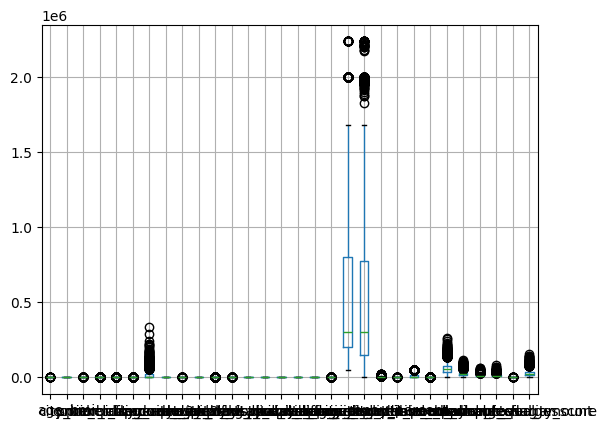

In [26]:
df.boxplot()

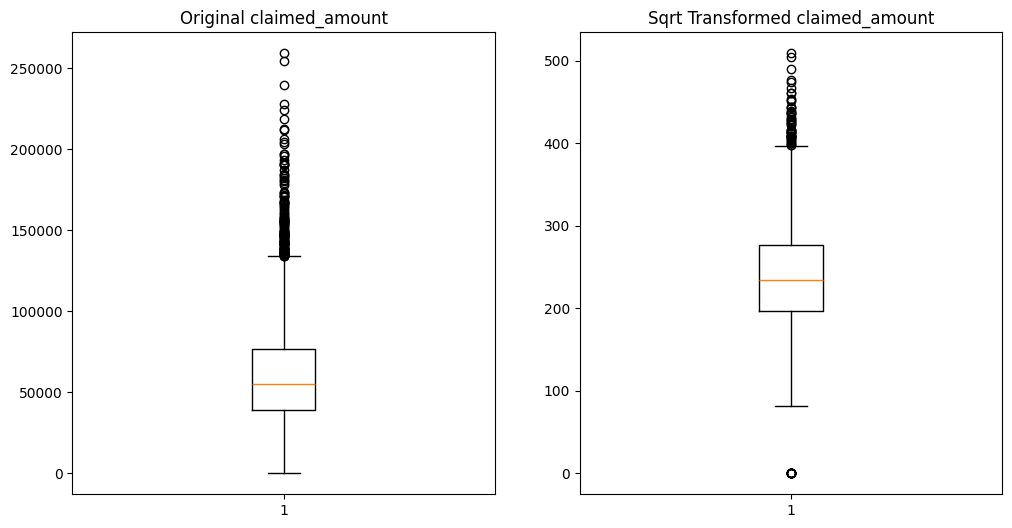

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define money columns
money_cols = [
    "prior_claim_amount_2yr",
    "sum_insured",
    "remaining_sum_insured",
    "room_rent_limit_per_day",
    "deductible_amount",
    "claimed_amount",
    "room_charges",
    "doctor_fees",
    "medicine_charges",
    "approved_amount"
]

# Apply sqrt transformation to money columns
for col in money_cols:
    if col in df.columns:
        df[col + "_sqrt"] = np.sqrt(df[col])

# Identify other numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
other_num_cols = [c for c in num_cols if c not in money_cols]

# Use IQR method to filter outliers in other numeric columns
mask = pd.Series(True, index=df.index)
for col in other_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask &= (df[col] >= lower) & (df[col] <= upper)

df_clean = df[mask]

# Compare boxplots before vs after for one money column
col = "claimed_amount"
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.boxplot(df[col].dropna())
plt.title(f"Original {col}")

plt.subplot(1,2,2)
plt.boxplot(df[col + "_sqrt"].dropna())
plt.title(f"Sqrt Transformed {col}")

plt.show()

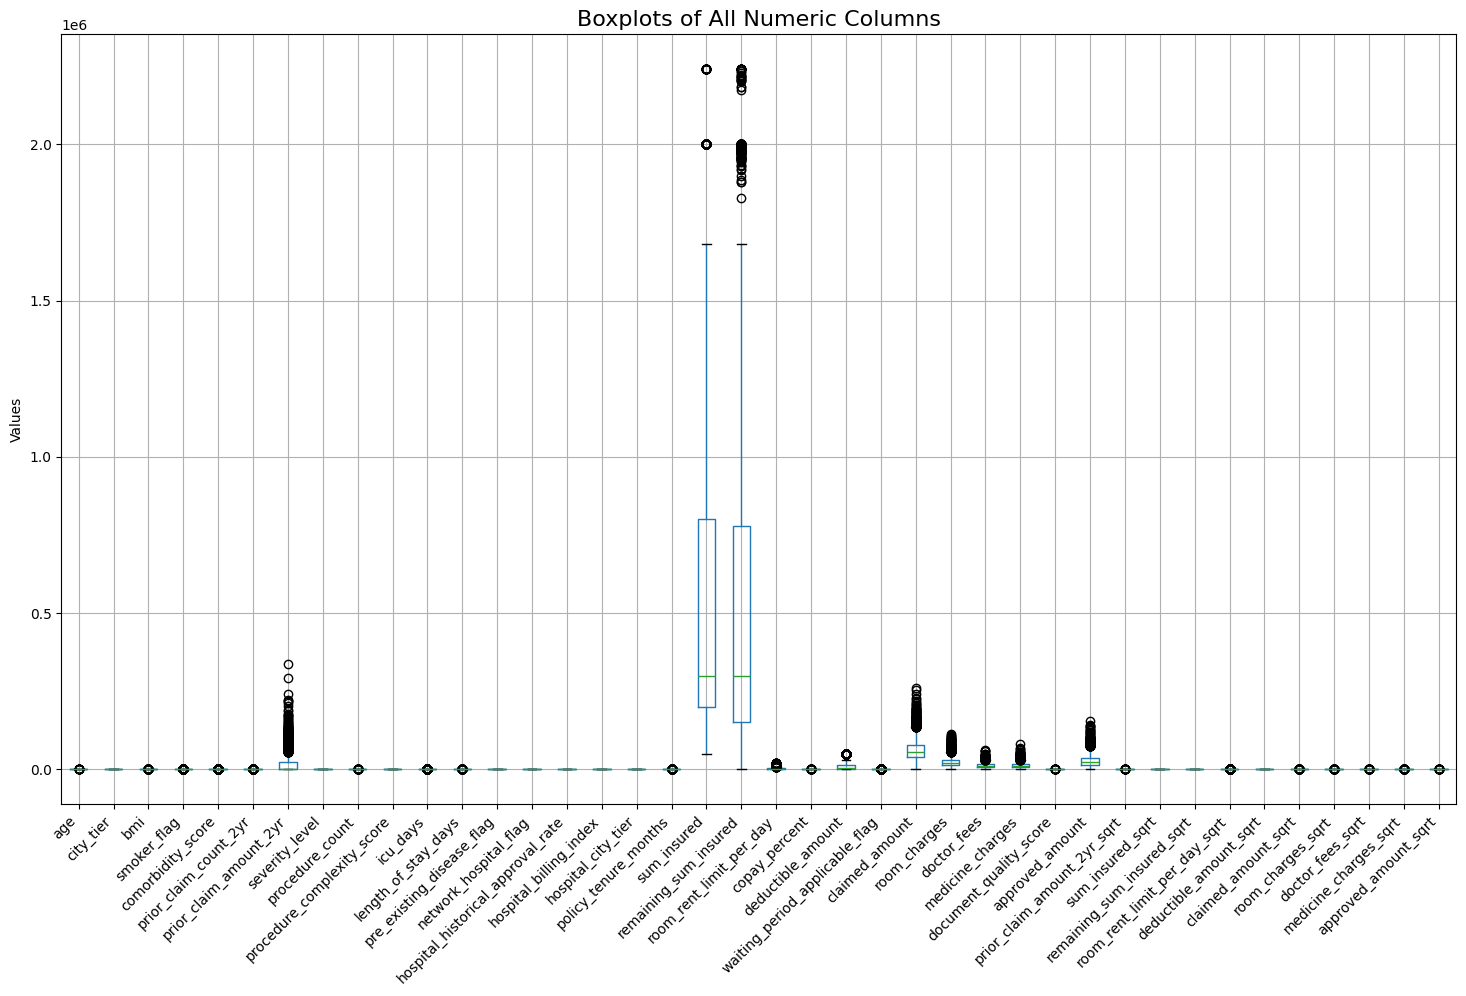

In [28]:
import matplotlib.pyplot as plt

# Select all numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 10))   # make the figure wide and tall
df[num_cols].boxplot()

plt.xticks(rotation=45, ha='right')  # rotate labels diagonally
plt.title("Boxplots of All Numeric Columns", fontsize=16)
plt.ylabel("Values")
plt.show()


In [29]:
import numpy as np
import pandas as pd

# Function to cap outliers using IQR
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)
    return df

# Define money columns
money_cols = [
    "prior_claim_amount_2yr",
    "sum_insured",
    "remaining_sum_insured",
    "room_rent_limit_per_day",
    "deductible_amount",
    "claimed_amount",
    "room_charges",
    "doctor_fees",
    "medicine_charges",
    "approved_amount"
]

# Apply sqrt transform to money columns
for col in money_cols:
    if col in df.columns:
        df[col + "_sqrt"] = np.sqrt(df[col])

# Apply capping to other numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
other_num_cols = [c for c in num_cols if c not in money_cols]

for col in other_num_cols:
    df = cap_outliers(df, col)



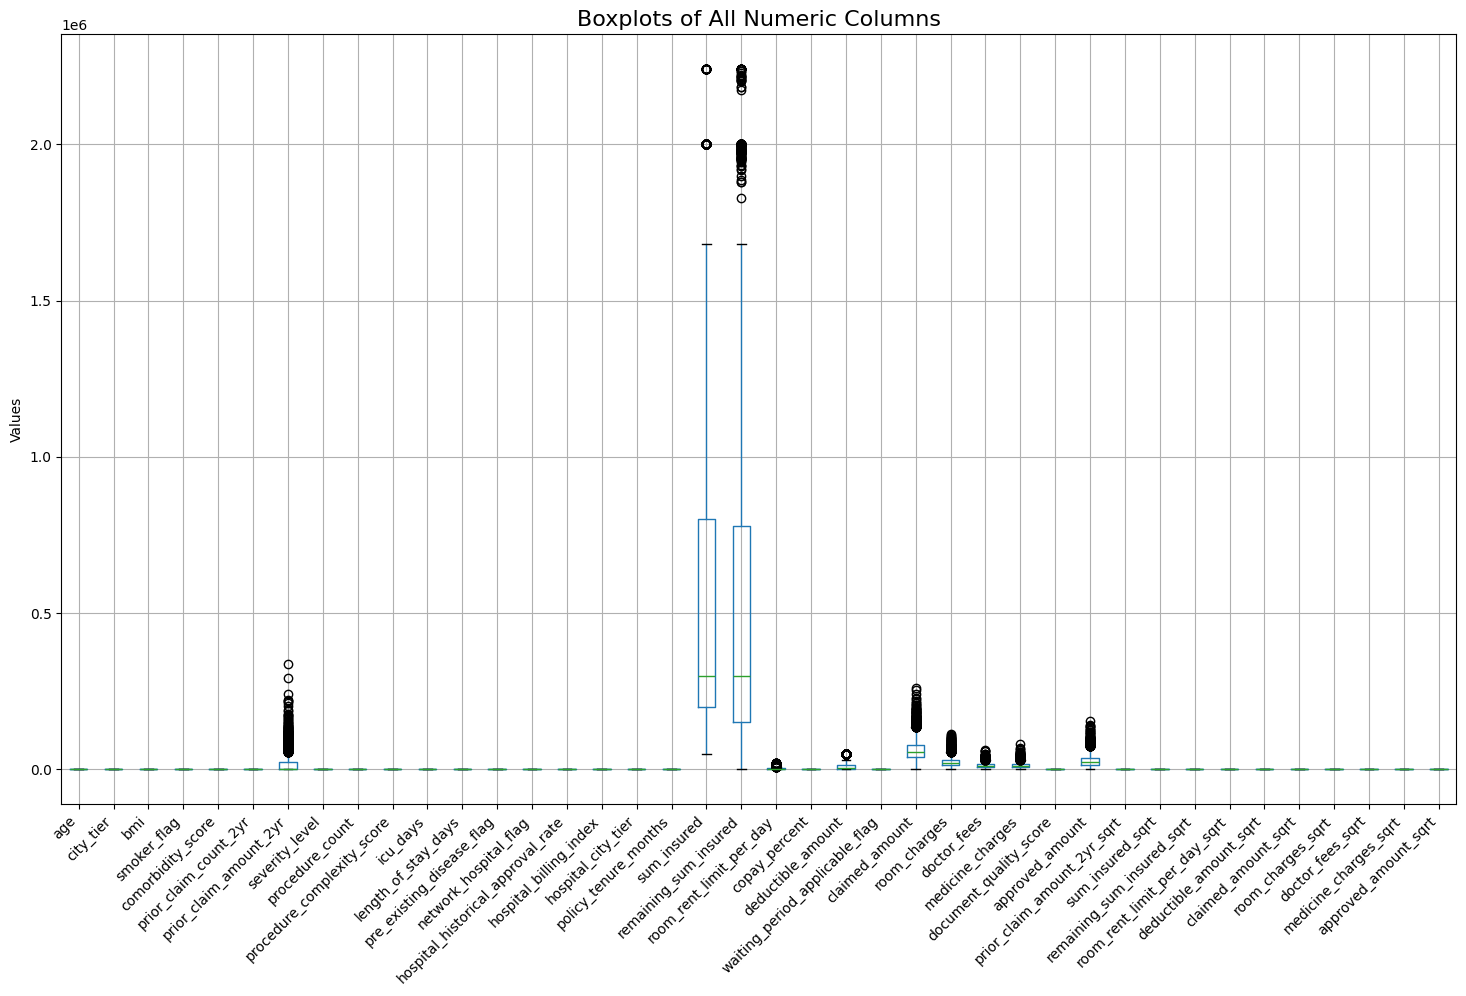

In [30]:
import matplotlib.pyplot as plt

# Select all numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 10))   # make the figure wide and tall
df[num_cols].boxplot()

plt.xticks(rotation=45, ha='right')  # rotate labels diagonally
plt.title("Boxplots of All Numeric Columns", fontsize=16)
plt.ylabel("Values")
plt.show()

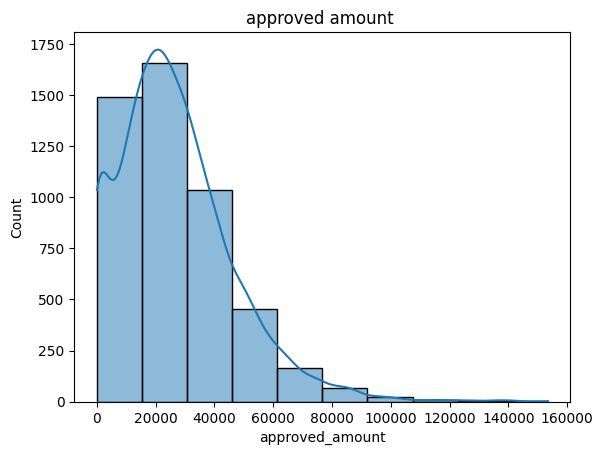

skewness 1.1510861609640726


In [31]:
#Distribution of Approved Amount
import seaborn as sns
sns.histplot(df["approved_amount"],bins=10,kde=True)
plt.title("approved amount ")
plt.show()
print("skewness",df["approved_amount"].skew())

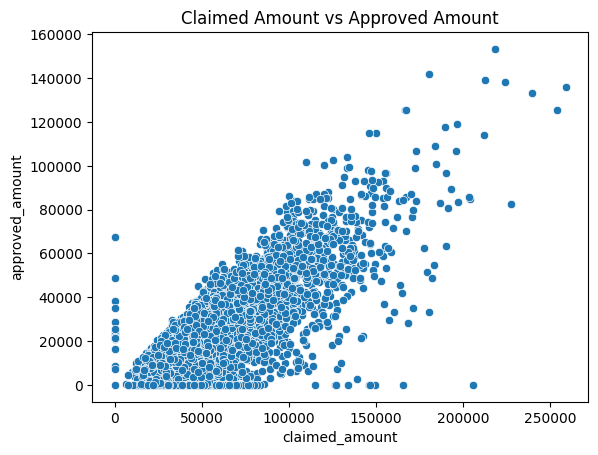

In [32]:
#Claimed Amount vs Approved Amount
sns.scatterplot(x = df['claimed_amount'],y = df['approved_amount'])
plt.title("Claimed Amount vs Approved Amount")
plt.show()

In [33]:
#Severity Level vs Approved Amount
severity_avg = df.groupby("severity_level")["approved_amount"].mean().reset_index()
print(severity_avg)


   severity_level  approved_amount
0               1     21322.204322
1               2     23382.741597
2               3     24602.717010
3               4     29968.694620
4               5     31739.862903


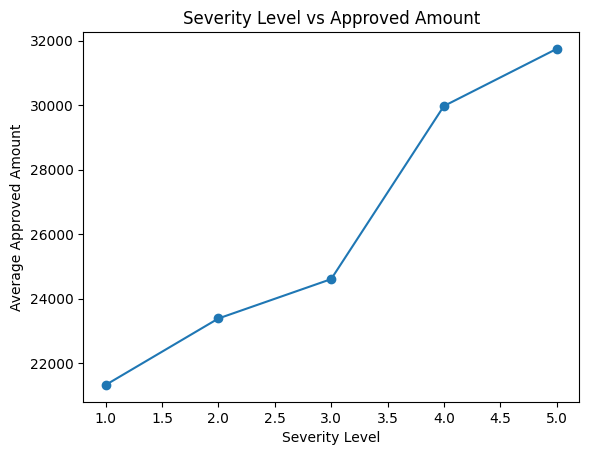

In [34]:
# Severity Level vs Approved Amount
import matplotlib.pyplot as plt

plt.figure()
plt.plot(severity_avg["severity_level"], 
         severity_avg["approved_amount"], marker='o')

plt.xlabel("Severity Level")
plt.ylabel("Average Approved Amount")
plt.title("Severity Level vs Approved Amount")
plt.show()


In [35]:
X = df.drop(["approved_amount", "approved_amount_sqrt"], axis=1)
y = df["approved_amount"]

In [40]:
X = pd.get_dummies(X, drop_first=True).astype(int)


In [41]:
X

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,diagnosis_category_Renal,diagnosis_category_Respiratory,diagnosis_category_Trauma,hospital_type_Govt,hospital_type_Trust,hospital_tier_B,hospital_tier_C,policy_type_Family,policy_type_Floater,policy_type_Individual
0,62,3,25,0,1,0,0,4,3,3,...,0,0,0,0,0,0,0,0,1,0
1,38,2,29,0,0,1,51576,4,5,3,...,0,0,0,0,0,0,1,1,0,0
2,50,2,28,0,1,0,0,1,0,3,...,0,0,0,0,0,0,0,0,0,1
3,6,1,25,0,2,0,0,4,3,5,...,0,0,0,0,0,0,0,0,0,0
4,58,1,23,0,2,0,0,4,4,5,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,57,2,23,0,3,1,11124,2,0,3,...,0,0,0,0,1,0,0,0,0,1
4995,33,1,31,0,1,0,0,3,0,6,...,0,1,0,1,0,0,0,0,1,0
4996,28,1,25,0,3,0,0,2,2,9,...,0,0,0,0,1,0,0,0,1,0
4997,64,1,24,0,3,1,63732,2,3,8,...,0,0,1,0,0,0,0,0,1,0


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])


In [44]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns in case some categories are missing in test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [45]:
X

,age,city_tier,bmi,smoker_flag,comorbidity_score,prior_claim_count_2yr,prior_claim_amount_2yr,severity_level,procedure_count,procedure_complexity_score,...,diagnosis_category_Renal,diagnosis_category_Respiratory,diagnosis_category_Trauma,hospital_type_Govt,hospital_type_Trust,hospital_tier_B,hospital_tier_C,policy_type_Family,policy_type_Floater,policy_type_Individual
0,62,3,25,0,1,0,0,4,3,3,...,0,0,0,0,0,0,0,0,1,0
1,38,2,29,0,0,1,51576,4,5,3,...,0,0,0,0,0,0,1,1,0,0
2,50,2,28,0,1,0,0,1,0,3,...,0,0,0,0,0,0,0,0,0,1
3,6,1,25,0,2,0,0,4,3,5,...,0,0,0,0,0,0,0,0,0,0
4,58,1,23,0,2,0,0,4,4,5,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,57,2,23,0,3,1,11124,2,0,3,...,0,0,0,0,1,0,0,0,0,1
4995,33,1,31,0,1,0,0,3,0,6,...,0,1,0,1,0,0,0,0,1,0
4996,28,1,25,0,3,0,0,2,2,9,...,0,0,0,0,1,0,0,0,1,0
4997,64,1,24,0,3,1,63732,2,3,8,...,0,0,1,0,0,0,0,0,1,0


In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=800,      # more trees
    max_depth=12,          # allow learning patterns
    min_samples_split=12,   # avoid tiny splits
    min_samples_leaf=5,    # prevent tiny leaves
    max_features=0.7,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [47]:
#random forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

MAE: 3799.284372923744
RMSE: 6115.001805266917
R2: 0.9123127335854841
Train R2: 0.9612419291829695
Test R2: 0.9123127335854841


In [49]:
import pandas as pd

# Convert categorical columns to dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_encoded, y, cv=5, scoring="r2")

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())



CV Scores: [0.90355066 0.92442497 0.91593647 0.92283295 0.91346041]
Mean CV R2: 0.9160410926948304


In [50]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=700,   # slightly deeper than 5 to avoid severe underfitting
    min_samples_leaf=150,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [51]:

#decision tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)
print("Train R2:", dt.score(X_train, y_train))
print("Test R2:", dt.score(X_test, y_test))


Decision Tree Results:
MAE: 6889.926149869399
RMSE: 10552.09753836306
R2: 0.7388915382589847
Train R2: 0.7560165828679796
Test R2: 0.7388915382589847


In [52]:

#gradient
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)


In [53]:
#evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Results:")
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2:", r2_gbr)
print("Train R2:", gbr.score(X_train, y_train))
print("Test R2:", gbr.score(X_test, y_test))


Gradient Boosting Results:
MAE: 3338.038375928132
RMSE: 4822.663693800176
R2: 0.9454597269799806
Train R2: 0.9620750036886541
Test R2: 0.9454597269799806


In [54]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gbr, X_encoded, y, cv=5, scoring="r2")

print("CV Scores:", scores)
print("Mean CV R2:", scores.mean())



CV Scores: [0.93432235 0.94830952 0.93658989 0.93616848 0.93609992]
Mean CV R2: 0.9382980312686469


In [56]:

#voting
from sklearn.ensemble import VotingRegressor

voting = VotingRegressor([
    ('rf', rf),
    ('dt', dt),
    ('gbr', gbr)
])

voting.fit(X_train, y_train)

y_pred_v = voting.predict(X_test)

print("Voting R2:", r2_score(y_test, y_pred_v))


Voting R2: 0.8997988760942438


In [57]:
scores = cross_val_score(voting, X_encoded, y, cv=5, scoring="r2")
print("Voting CV Mean:", scores.mean())


Voting CV Mean: 0.8980080830046451


In [58]:
#stacking
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

stack = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('dt', dt),
        ('gbr', gbr)
    ],
    final_estimator=LinearRegression()
)

stack.fit(X_train, y_train)

y_pred_s = stack.predict(X_test)

print("Stacking R2:", r2_score(y_test, y_pred_s))


Stacking R2: 0.9515692282773658


In [59]:
import pandas as pd

feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))


claimed_amount                0.260878
room_charges                  0.160752
deductible_amount             0.122247
deductible_amount_sqrt        0.106679
doctor_fees                   0.103808
medicine_charges              0.088122
doctor_fees_sqrt              0.034781
remaining_sum_insured_sqrt    0.028448
remaining_sum_insured         0.023035
copay_percent                 0.022736
dtype: float64


In [60]:
mae_vote = mean_absolute_error(y_test, y_pred_v)
rmse_vote = np.sqrt(mean_squared_error(y_test, y_pred_v))
r2_vote = r2_score(y_test, y_pred_v)


In [61]:
mae_stack = mean_absolute_error(y_test, y_pred_s)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_s))
r2_stack = r2_score(y_test, y_pred_s)


In [62]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Voting Regressor",
        "Stacking Regressor"
    ],
    "MAE": [
        mae_dt,
        mae,
        mae_gbr,
        mae_vote,
        mae_stack
    ],
    "RMSE": [
        rmse_dt,
        rmse,
        rmse_gbr,
        rmse_vote,
        rmse_stack
    ],
    "R2": [
        r2_dt,
        r2,
        r2_gbr,
        r2_vote,
        r2_stack
    ]
})

print(comparison)



                Model          MAE          RMSE        R2
0       Decision Tree  6889.926150  10552.097538  0.738892
1       Random Forest  3799.284373   6115.001805  0.912313
2   Gradient Boosting  3338.038376   4822.663694  0.945460
3    Voting Regressor  4285.345796   6536.791312  0.899799
4  Stacking Regressor  3119.671581   4544.530459  0.951569


In [63]:
comparison = comparison.sort_values(by="R2", ascending=False)
print(comparison)


                Model          MAE          RMSE        R2
4  Stacking Regressor  3119.671581   4544.530459  0.951569
2   Gradient Boosting  3338.038376   4822.663694  0.945460
1       Random Forest  3799.284373   6115.001805  0.912313
3    Voting Regressor  4285.345796   6536.791312  0.899799
0       Decision Tree  6889.926150  10552.097538  0.738892


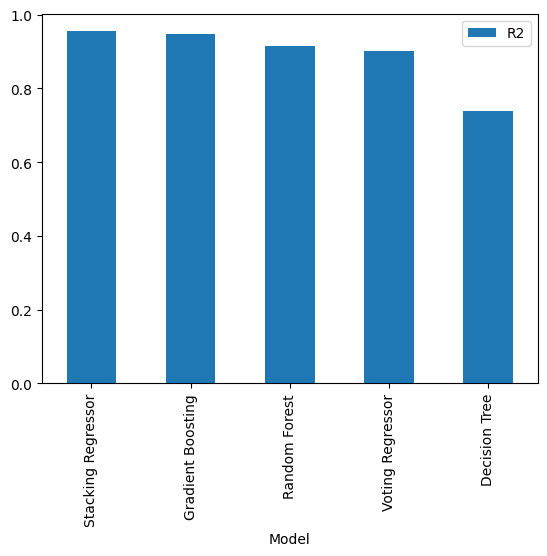

In [55]:
comparison.plot(x="Model", y="R2", kind="bar")
plt.show()

In [ ]:
#INTERPRETATION
Multiple regression models were implemented including Decision Tree, Random Forest, Gradient Boosting, Voting Regressor, and Stacking Regressor.
Model performance was evaluated using MAE, RMSE, and R² metrics along with cross-validation. 
    Among all models, the Stacking Regressor achieved the highest R² score of 0.954, outperforming individual and ensemble models. 
    
The stacking approach effectively combined predictions from multiple tree-based models, resulting in improved generalization performance. 
    Therefore, the Stacking Regressor was selected as the final model for predicting approved loan amounts.